In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\5_comp
scenario=5comp_equal  K_MODEL=5  K_TRUE=5
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' live-component support (union over
# samplers); the True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted-support, live components):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted-support, live components):
  Alt1       [-39.88, +22.96]
  Alt2       [-27.72, +46.70]
  Alt3       [-22.82, +21.15]
  Price      [-30.14, +17.03]


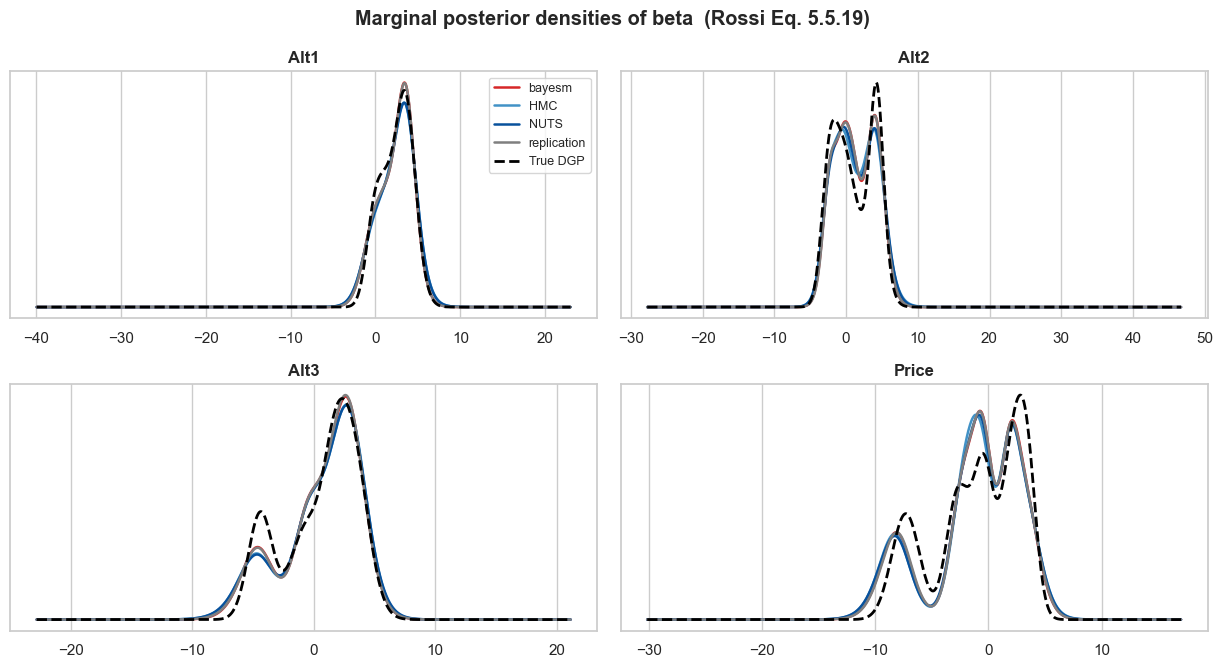

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06873  0.02628  0.00445  0.04176       0.10488
            Alt2     0.07024  0.02043  0.00491  0.08533       0.23578
            Alt3     0.08890  0.04656  0.00737  0.06378       0.19772
            Price    0.14099  0.09846  0.01902  0.13913       0.38285
HMC         Alt1     0.09484  0.10284  0.00828  0.06229       0.19512
            Alt2     0.08843  0.08133  0.00748  0.08904       0.24561
            Alt3     0.11147  0.09188  0.01129  0.08036       0.26503
            Price    0.15996  0.14319  0.02412  0.15086       0.41506
NUTS        Alt1     0.09244  0.05565  0.00792  0.06253       0.19028
            Alt2     0.08397  0.03420  0.00690  0.09174       0.24688
            Alt3     0.11268  0.08869  0.01155  0.07964       0.26799
            Price    0.15606  0.13139  0.02296  0.14731       0.40810
replication Alt1     0.06740  0.02505  0.00428  0.04089       0.10439
            Alt2     0.07167  0.02120  0.00511  0.08623       0.24403
            Alt3     0.09140  0.05189  0.00773  0.06311       0.20319
            Price    0.13864  0.09436  0.01843  0.13863       0.37798

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.342,2.391,2.394,2.344,2.388
Alt2,1.315,1.329,1.344,1.324,1.142
Alt3,0.634,0.646,0.653,0.633,0.560
Price,-1.125,-1.153,-1.146,-1.115,-1.000


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,4.155,4.796,4.658000,4.146,3.603
Alt2,7.810,8.755,8.375000,7.766,8.496
Alt3,10.173,10.818,10.821000,10.191,9.511
Price,16.564,17.344,17.214001,16.458,15.138


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a
      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).
      It cannot detect multimodality a lone chain never explored - the
      between-chain R-hat comes from the 2-chain runs.

--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,7,369.246,823.711,1.015,1.004
Alt2,8,308.620,635.631,1.010,1.003
Alt3,14,267.885,663.525,1.010,1.004
Price,16,113.131,774.231,1.034,1.010


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,7,216.795,589.374,1.026,1.010
Alt2,8,11.016,218.777,1.137,1.053
Alt3,16,116.538,369.131,1.028,1.009
Price,16,6.815,205.996,1.201,1.034


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,7,749.799,1513.466,1.003,1.001
Alt2,8,349.374,979.760,1.007,1.003
Alt3,16,497.438,1271.335,1.010,1.004
Price,16,167.328,1197.859,1.015,1.004


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,7,396.115,789.621,1.003,1.001
Alt2,8,416.781,629.621,1.018,1.007
Alt3,14,277.880,570.420,1.011,1.005
Price,16,107.384,929.104,1.006,1.003


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                   
Alt1  Mean     917.4456  1.0039
      Var      736.1980  1.0045
Alt2  Mean    1374.9229  1.0006
      Var      496.1482  1.0018
Alt3  Mean    1190.6640  1.0011
      Var      304.3559  1.0043
Price Mean    1010.1233  1.0050
      Var      220.4905  1.0172

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean    408.1168  1.0062
      Var      53.3027  1.0380
Alt2  Mean    341.2741  1.0045
      Var      23.0780  1.0734
Alt3  Mean    312.0287  1.0037
      Var     245.4722  1.0035
Price Mean    155.4249  1.0256
      Var     228.9740  1.0103

--- NUTS ---


ESS    Rhat
param moment                   
Alt1  Mean    1516.5003  1.0010
      Var      658.3542  1.0033
Alt2  Mean    2888.0638  1.0007
      Var      801.1726  1.0038
Alt3  Mean    1777.3641  1.0010
      Var      831.1190  1.0041
Price Mean    3253.2997  1.0001
      Var      953.0532  1.0011

--- replication ---


ESS    Rhat
param moment                   
Alt1  Mean     778.5467  1.0005
      Var      682.1624  1.0011
Alt2  Mean    1891.1872  1.0007
      Var      439.3768  1.0094
Alt3  Mean    1110.6203  1.0014
      Var      362.0507  1.0012
Price Mean    1404.9836  1.0003
      Var      196.4423  1.0015


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
